In [1]:
from collections import defaultdict
import random
import matplotlib.pyplot as plt
import numpy as np

class GridWorld:
    """ A grid world environment (width x height) for reinforcement learning.
    Each cell in the grid can be occupied by an agent, a goal, or an obstacle.
     
    
    Args:
        width (int): The width of the grid world.
        height (int): The height of the grid world.

    """
    def __init__(self, width: int, height: int):
        self.width = width
        self.height = height
        self.size = (width,  height)
        self.obstacles = set()
        self.goals = defaultdict(float)  # {(x, y): reward}

    
    def add_obstacle(self, x: int, y: int):
        """ Add an obstacle at the specified coordinates (x, y). """
        if 1 <= x <= self.width and 1 <= y <= self.height:
            self.obstacles.add((x, y))
        else:
            raise ValueError("Coordinates are out of bounds.")
        
    def add_obstacles(self, obstacle_list: list[tuple[int, int]]):
        """ Add multiple obstacles from a list of coordinates. """
        for x, y in obstacle_list:
            self.add_obstacle(x, y)
        
    def remove_obstacle(self, x: int, y: int):
        """ Remove an obstacle from the specified coordinates (x, y). """
        self.obstacles.discard((x, y))
    
    def remove_obstacles(self, obstacle_list: list[tuple[int, int]]):
        """ Remove multiple obstacles from a list of coordinates. """
        for x, y in obstacle_list:
            self.remove_obstacle(x, y)
    
    def add_goal(self, x: int, y: int, reward: float = 1.0):
        """ Add a goal at the specified coordinates (x, y). """
        if 1 <= x <= self.width and 1 <= y <= self.height:
            if (x, y) in self.obstacles:
                raise ValueError("Cannot place a goal on an obstacle.")

            self.goals[(x, y)] = reward  

        else:
            raise ValueError("Coordinates are out of bounds.")
        
    
    def add_goals(self, goal_list: list[tuple[int, int, float]]):
        """ Add multiple goals from a list of coordinates. """
        for x, y, reward in goal_list:
            self.add_goal(x, y, reward)
    
    def remove_goal(self, x: int, y: int):
        """ Remove a goal from the specified coordinates (x, y). """
        for goal in list(self.goals):
            if goal[0] == x and goal[1] == y:
                self.goals.pop(goal)
                break

    def remove_goals(self, goal_list: list[tuple[int, int]]):
        """ Remove multiple goals from a list of coordinates. """
        for x, y in goal_list:
            self.remove_goal(x, y)
    
    def display(self):
        """ Displays a clean grid with a coordinate legend for rewards. """
        print(f"\n{' Grid World ':~^30}")
        
        for y in range(self.height, 0, -1):
            row = []
            for x in range(1, self.width + 1):
                if (x, y) in self.obstacles:
                    row.append("  █  ") # Obstacle
                elif (x, y) in self.goals:
                    row.append("  G  ") # Goal Marker
                else:
                    row.append("  .  ") # Empty
            print(f"{y:2d} |" + "".join(row) + "|")

        # X-axis labels
        print("    " + "-" * (self.width * 5))
        print("    " + "".join([f" {x:2d}  " for x in range(1, self.width + 1)]))

        # Reward Legend
        if self.goals:
            print("\n--- Rewards ---")
            for (x, y), val in self.goals.items():
                print(f"Goal at ({x}, {y}): {val:.2f}")
    
    def random_world(self, num_obstacles: int, num_goals: int, reward_range: tuple[float, float] = (1.0, 10.0), seed: int = None):
        """ Generate a random world with a specified number of obstacles and goals. """
        if seed is not None:
            random.seed(seed)
        # Clear existing obstacles and goals
        self.obstacles.clear()
        self.goals.clear()
        
        # Add random obstacles
        while len(self.obstacles) < num_obstacles:
            x = random.randint(1, self.width)
            y = random.randint(1, self.height)
            self.add_obstacle(x, y)
        
        # Add random goals
        while len(self.goals) < num_goals:
            x = random.randint(1, self.width)
            y = random.randint(1, self.height)
            if (x, y) not in self.obstacles:
                reward = random.uniform(*reward_range)
                self.add_goal(x, y, reward)
    
    def generate_maze_prims(self, seed: int | None = None):
        """
        Generate a perfect maze using Randomized Prim's Algorithm.
        Empty cells are corridors; obstacles are walls.
        """
        if seed is not None:
            random.seed(seed)

        W, H = self.width, self.height

        self.obstacles = {(x, y) for x in range(1, W + 1)
                                for y in range(1, H + 1)}

        def neighbors(x, y):
            for dx, dy in [(2,0), (-2,0), (0,2), (0,-2)]:
                nx, ny = x + dx, y + dy
                if 1 <= nx <= W and 1 <= ny <= H:
                    yield nx, ny

        def wall_between(x1, y1, x2, y2):
            return ((x1 + x2)//2, (y1 + y2)//2)

        start_x = random.randrange(1, W + 1, 2)
        start_y = random.randrange(1, H + 1, 2)

        self.remove_obstacle(start_x, start_y)

        frontier = []
        for nx, ny in neighbors(start_x, start_y):
            frontier.append((start_x, start_y, nx, ny))

        while frontier:
            x, y, nx, ny = frontier.pop(random.randrange(len(frontier)))

            if (nx, ny) in self.obstacles:
                wx, wy = wall_between(x, y, nx, ny)

                self.remove_obstacle(wx, wy)
                self.remove_obstacle(nx, ny)

                for nnx, nny in neighbors(nx, ny):
                    if (nnx, nny) in self.obstacles:
                        frontier.append((nx, ny, nnx, nny))
    
    def generate_maze_recursive_backtracking(self, seed: int | None = None):
        """
        Generate a perfect maze using Recursive Backtracking Algorithm.
        Empty cells are corridors; obstacles are walls.
        This differs from Prim's by using a depth-first search approach.
        """
        if seed is not None:
            random.seed(seed)

        W, H = self.width, self.height

        # Initialize all cells as walls (obstacles)
        self.obstacles = {(x, y) for x in range(1, W + 1)
                                for y in range(1, H + 1)}

        def is_valid(x, y):
            return 1 <= x <= W and 1 <= y <= H

        def get_neighbors(x, y):
            neighbors = []
            for dx, dy in [(2, 0), (-2, 0), (0, 2), (0, -2)]:
                nx, ny = x + dx, y + dy
                if is_valid(nx, ny):
                    neighbors.append((nx, ny))
            return neighbors

        def carve_passage(cx, cy, visited):
            visited.add((cx, cy))
            self.remove_obstacle(cx, cy)

            neighbors = get_neighbors(cx, cy)
            random.shuffle(neighbors)

            for nx, ny in neighbors:
                if (nx, ny) not in visited:
                    # Remove the wall between current and neighbor
                    wx, wy = (cx + nx) // 2, (cy + ny) // 2
                    self.remove_obstacle(wx, wy)
                    carve_passage(nx, ny, visited)

        # Start from a random odd position
        start_x = random.randrange(1, W + 1, 2)
        start_y = random.randrange(1, H + 1, 2)

        visited = set()
        carve_passage(start_x, start_y, visited)

    def generate_maze_with_loops(self, seed: int | None = None, loop_probability: float = 0.1):
        """
        Generate a maze with loops by first creating a perfect maze using Recursive Backtracking,
        then randomly removing some walls to introduce loops. This makes the maze more complex,
        as simple wall-following rules may not guarantee finding the goal due to potential cycles.
        
        Args:
            seed (int | None): Random seed for reproducibility.
            loop_probability (float): Probability of removing a wall to create a loop (0.0 to 1.0).
        """
        if seed is not None:
            random.seed(seed)

        # First, generate a perfect maze
        self.generate_maze_recursive_backtracking(seed)

        W, H = self.width, self.height

        # Now, randomly remove some walls to create loops
        for x in range(1, W + 1):
            for y in range(1, H + 1):
                if (x, y) in self.obstacles:
                    # Check if removing this wall would create a loop
                    # For simplicity, remove with given probability if it's a wall between two passages
                    # But to ensure it's a wall between passages, check neighbors
                    neighbors = [(x+1, y), (x-1, y), (x, y+1), (x, y-1)]
                    passage_count = sum(1 for nx, ny in neighbors if 1 <= nx <= W and 1 <= ny <= H and (nx, ny) not in self.obstacles)
                    if passage_count >= 2 and random.random() < loop_probability:
                        self.remove_obstacle(x, y)
    
    def plot_gridworld(self,start_pos=None, figsize=(8, 8)):
        """
        Plots the GridWorld with obstacles, goals, and a starting point 'S'.
        """
        width = self.width
        height = self.height
        obstacles = self.obstacles
        goals = self.goals

        fig, ax = plt.subplots(figsize=figsize)

        # 1. Draw the Grid and Elements
        for x in range(1, width + 1):
            for y in range(1, height + 1):
                state = (x, y)
                
                # Draw Obstacles (Black blocks)
                if state in obstacles:
                    ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, color='black'))
                
                # Draw Goals (Green blocks with reward text)
                elif state in goals:
                    ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, color='#2ecc71'))
                    goal_value = goals[state]
                    ax.text(x, y, f"G", ha='center', va='center',
                            color='white', fontsize=10, fontweight='bold')
                
                # Draw Start Point (Blue 'S')
                elif start_pos and state == start_pos:
                    ax.text(x, y, "S", ha='center', va='center', 
                            color='#3498db', fontsize=20, fontweight='bold')
                
                # Draw Empty Cells (Optional: dots or just empty)
                else:
                    ax.plot(x, y, marker='.', color='#bdc3c7', markersize=2)

        # 2. Final Formatting (Matching your style)
        ax.set_xlim(0.5, width + 0.5)
        ax.set_ylim(0.5, height + 0.5)
        ax.set_xticks(range(1, width + 1))
        ax.set_yticks(range(1, height + 1))
        ax.set_aspect('equal')
        # ax.grid(True, which='both', color='#ecf0f1', linewidth=0.5)
        
        plt.title("Grid World Environment")
        plt.show()

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_optimal_policy(model, agent_idx=0, figsize=(8, 8), show_steps=False):
    """
    Plots the optimal policy for a specific agent.
    Fixes IndexError by checking bounds before indexing the Q-table.
    """
    width = model.width
    height = model.height
    obstacles = model.obstacles
    goals = model.goals
    Q_table = model.Q[agent_idx] 
    fixed_start = model.fixed_start_point
    
    # Map index to vector (0: up, 1: down, 2: left, 3: right)
    action_to_arrow = {
        0: (0, 1), 1: (0, -1), 2: (-1, 0), 3: (1, 0)
    }

    fig, ax = plt.subplots(figsize=figsize)


    def get_steps_to_goal(start_state):
        curr_x, curr_y = start_state
        steps = 0
        visited = set()
        max_dist = width * height 
        
        while (curr_x, curr_y) not in goals and steps < max_dist:
            if (curr_x, curr_y) in visited:
                return None 
            visited.add((curr_x, curr_y))
            
            # Bounds check before indexing
            if not (1 <= curr_x <= width and 1 <= curr_y <= height):
                return None
            
            best_action = np.argmax(Q_table[curr_x-1, curr_y-1])
            dx, dy = action_to_arrow[best_action]
            
            curr_x, curr_y = curr_x + dx, curr_y + dy
            steps += 1
            
            if (curr_x, curr_y) in obstacles:
                return None
                
        return steps if (curr_x, curr_y) in goals else None


    for x in range(1, width + 1):
        for y in range(1, height + 1):
            state = (x, y)
            if state in obstacles:
                ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, color='black'))
            elif state in goals:
                color = '#2ecc71' if show_steps else 'green'
                ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, color=color))
                # If show_steps is False, show the reward value
                label = "GOAL" if show_steps else f"{goals[state]:.1f}"
                ax.text(x, y, label, ha='center', va='center', 
                        color='white', fontsize=10, fontweight='bold')


    if show_steps:
        for x in range(1, width + 1):
            for y in range(1, height + 1):
                if (x, y) in obstacles or (x, y) in goals: continue
                steps = get_steps_to_goal((x, y))
                txt, col = (str(steps), '#2c3e50') if steps is not None else ("∞", "red")
                ax.text(x, y, txt, ha='center', va='center', fontsize=14, fontweight='bold', color=col)
    else:
        if fixed_start is not None:
            # Trace path from fixed start point only
            curr_x, curr_y = fixed_start
            path_states = set()
            for _ in range(width * height):
                # STOP if we hit a goal, obstacle, or go out of bounds
                if (curr_x, curr_y) in goals or (curr_x, curr_y) in obstacles:
                    break
                if not (1 <= curr_x <= width and 1 <= curr_y <= height):
                    break
                if (curr_x, curr_y) in path_states:
                    break
                
                path_states.add((curr_x, curr_y))
                
                # Safe to index now
                best_action = np.argmax(Q_table[curr_x-1, curr_y-1])
                dx, dy = action_to_arrow[best_action]
                
                ax.arrow(curr_x, curr_y, 0.3 * dx, 0.3 * dy,
                         head_width=0.2, head_length=0.2, fc='blue', ec='blue')
                
                curr_x += dx
                curr_y += dy
        else:
            # Show arrows for the entire grid
            for x in range(1, width + 1):
                for y in range(1, height + 1):
                    if (x, y) in obstacles or (x, y) in goals: continue
                    best_action = np.argmax(Q_table[x-1, y-1])
                    dx, dy = action_to_arrow[best_action]
                    ax.arrow(x, y, 0.3 * dx, 0.3 * dy,
                             head_width=0.15, head_length=0.15, fc='blue', ec='blue')


    ax.set_xlim(0.5, width + 0.5)
    ax.set_ylim(0.5, height + 0.5)
    ax.set_xticks(range(1, width + 1))
    ax.set_yticks(range(1, height + 1))
    ax.set_aspect('equal')
    # ax.grid(True, which='both', color='#ecf0f1', linewidth=0.5)
    
    plt.title(f"Policy (Agent {agent_idx}): {'Steps' if show_steps else 'Arrows'}")
    plt.show()

In [3]:
import random
from tqdm import tqdm
import numpy as np

class Dyna_Q_RefinedV3:
    """
    Dyna-Q algorithm working with a GridWorld environment.

    Args:
        world (GridWorld): The environment in which the agent will learn and plan.
    """
    def __init__(self, world):
        self.world = world
        self.width, self.height = world.size
        self.obstacles = world.obstacles
        self.goals = world.goals
        self.n_actions = 4  # 0: up, 1: down, 2: left, 3: right
        self.available_states = {(x, y) for x in range(1, self.width + 1) 
                                 for y in range(1, self.height + 1)} - self.obstacles
        
        # Create masked grid for obstacles (True for obstacles, False for free cells)
        self.obs_mask = np.zeros((self.width + 1, self.height + 1), dtype=bool)
        for x, y in self.obstacles:
            self.obs_mask[x, y] = True

        # Create reward grid for goals (0 for non-goal cells, reward value for goal cells)
        self.reward_grid = np.zeros((self.width + 1, self.height + 1))
        self.goal_mask = np.zeros((self.width + 1, self.height + 1), dtype=bool)
        for (x, y), reward in self.goals.items():
            self.reward_grid[x, y] = reward
            self.goal_mask[x, y] = True



    def update_world(self, new_world):
        """
        Updates the internal representation of the environment.
        Useful for non-stationary environments (e.g., blocking/unblocking paths).
        """
        self.world = new_world
        self.width, self.height = new_world.size
        self.obstacles = new_world.obstacles
        self.goals = new_world.goals
        
        # Re-calculate available states for the new configuration
        self.available_states = {
            (x, y) for x in range(1, self.width + 1) 
            for y in range(1, self.height + 1)
        } - self.obstacles

        # Create a grid of Falses (0s)
        self.obs_mask = np.zeros((self.width + 1, self.height + 1), dtype=bool)
        for x, y in self.obstacles:
            self.obs_mask[x, y] = True
        
        # Create reward grid for goals (0 for non-goal cells, reward value for goal cells)
        self.reward_grid = np.zeros((self.width + 1, self.height + 1))
        self.goal_mask = np.zeros((self.width + 1, self.height + 1), dtype=bool)
        for (x, y), reward in self.goals.items():
            self.reward_grid[x, y] = reward
            self.goal_mask[x, y] = True
 

    def initialize(self, num_plan, seed=None, set_zero=False, num_episode=None, alpha=0.1, epsilon=0.1, 
                   gamma=0.9, k=0.1, fixed_start_point=None, max_steps=10000, max_timestep=None, initalize_memory=True, num_agents=1):
        
        self.num_plan = num_plan
        self.num_episode = num_episode if num_episode is not None else float('inf')
        self.alpha = alpha
        self.gamma = gamma
        self.k = k
        self.epsilon = epsilon
        self.fixed_start_point = fixed_start_point
        self.max_steps = max_steps
        self.max_timestep = max_timestep if max_timestep is not None else 2 **(31) - 1
        self.num_agents = num_agents
        self.agent_idx = np.arange(self.num_agents)

        if seed is not None: 
            random.seed(seed)
            np.random.seed(seed)

        if initalize_memory:
            if set_zero:
                self.Q = np.zeros((num_agents, self.width, self.height, self.n_actions))
            else:
                self.Q = np.random.normal(0, 1, (num_agents, self.width, self.height, self.n_actions))
                
            self.model = np.zeros(
                (num_agents, self.width, self.height, self.n_actions, 4)
            )

            self.cumulative_rewards = []
            self.current_cumulative = np.zeros(num_agents)
            self.time_stamp = [0]
            self.num_steps = []

            self.time_step = 0
            self.pos_tracker = []
        

    def get_bonus(self, s, a, k):

        last_time = self.model[
            self.agent_idx,
            s[:,0]-1,
            s[:,1]-1,
            a,
            3
        ]

        tau = self.time_step - last_time
        return k * np.sqrt(tau)

    def get_action(self, state, epsilon, k=0):

        action = np.random.choice(self.n_actions, size=self.num_agents)
        exploit_mask = np.random.random(self.num_agents) >= epsilon
        num_exploiting = np.sum(exploit_mask)

        if num_exploiting > 0:
            q_values = self.Q[self.agent_idx, state[:, 0]-1, state[:, 1]-1]
            
            max_vals = np.max(q_values, axis=-1, keepdims=True)
            is_max = (q_values == max_vals)
            
            # Add noise to break symmetry among actions with the same max Q-value
            tie_breaker = is_max * np.random.random(q_values.shape)
            
            best_actions = np.argmax(tie_breaker, axis=-1)
            action[exploit_mask] = best_actions[exploit_mask]

        return action
    

    def take_action(self, state, action):
        move = np.array([
                [0,  1], # Up
                [0, -1], # Down
                [-1, 0], # Left
                [1,  0]  # Right
            ])
        
        # Move to next state
        next_state = state + move[action]

        # Boundary(Out-of-Bound) and obstacle check
        oob = (next_state[:, 0] < 1) | (next_state[:, 0] > self.width) | (next_state[:, 1] < 1) | (next_state[:, 1] > self.height)
        safe_idx = np.clip(next_state, 0, [self.width, self.height])
        hit_obstacle = self.obs_mask[safe_idx[:, 0], safe_idx[:, 1]]
        invalid = oob | hit_obstacle
        next_state = np.where(invalid[:, np.newaxis], state, next_state)

        return next_state, self.reward_grid[next_state[:, 0], next_state[:, 1]]

    def return_to_start(self, num_states):

        if self.fixed_start_point is not None:
            return np.array(self.fixed_start_point)[:,None].T.repeat(num_states, axis=0)
        else:
            states = list(self.available_states)
            indices = np.random.choice(len(states), size=num_states, replace=True)
            return np.array(states)[indices]
    
    def model_update(self, state, action, reward, next_state):
        update_data = np.column_stack([reward, next_state[:, 0] - 1, next_state[:, 1] - 1, np.full(len(state), self.time_step)])
        self.model[self.agent_idx, state[:, 0]-1, state[:, 1]-1, action] = update_data
            

    def train(self, num_plan, num_episode=None, alpha=0.1, epsilon=0.1, gamma=0.9, k=0.1, seed=None, 
              fixed_start_point=None, max_steps=10000, set_zero=False, max_timestep=None, initalize_memory=True, num_agents=1):

        self.initialize(num_plan=num_plan, seed=seed, set_zero=set_zero, num_episode=num_episode, alpha=alpha, epsilon=epsilon, 
                        gamma=gamma, k=k, fixed_start_point=fixed_start_point, max_steps=max_steps, max_timestep=max_timestep, initalize_memory=initalize_memory, num_agents=num_agents)
        
        
        # Initialize state
        state = self.return_to_start(num_states=self.num_agents)
        self.initial_time_step = self.time_step + 1

        for step in tqdm(range(self.initial_time_step, self.max_timestep + 1)):
            self.pos_tracker.append(state)
            self.time_step += 1

            # Choose action
            action = self.get_action(state, epsilon, k)


            # Take action and observe next state and reward
            next_state, reward = self.take_action(state, action)

            self.current_cumulative += reward
            self.cumulative_rewards.append(self.current_cumulative.copy())
            
            # Direct RL Update
            self.update_q(state, action, reward, next_state, alpha, gamma)
            
            # Model Update
            self.model_update(state, action, reward, next_state)


            # Planning
            for _ in range(num_plan):
                valid = self.model[...,3] > 0
                valid_flat = valid.reshape(self.num_agents, -1)

                choices = [np.random.choice(np.where(valid_flat[i])[0]) for i in range(self.num_agents)]

                idx_x, idx_y, idx_a = np.unravel_index(choices, (self.width, self.height, self.n_actions))

                s_sim = np.stack((idx_x+1, idx_y+1), axis=-1)
                a_sim = idx_a

                data = self.model[self.agent_idx, s_sim[:, 0] - 1, s_sim[:, 1] - 1, a_sim]

                r_sim = data[:, 0]
                next_s_sim = data[:, 1:3].astype(int) + 1

                self.update_q_plan(s_sim, a_sim, r_sim, next_s_sim, alpha, gamma, k)
            
            state = next_state

            if self.time_step > self.max_timestep:
                self.pos_tracker.append(state)
                return
            
            # state hit goal, return to start
            hit_goal = self.goal_mask[state[:, 0], state[:, 1]]

            if np.any(hit_goal):
                self.num_steps.append(self.time_step - self.time_stamp[-1])
                self.time_stamp.append(self.time_step)
                
                # Reset state for agents that hit the goal
                state[hit_goal] = self.return_to_start(num_states=hit_goal.sum())

                
                if len(self.num_steps) >= self.num_episode:
                    return

    
    def update_q(self, s, a, r, next_s, alpha, gamma):

        best_q = np.max(self.Q[self.agent_idx, next_s[:, 0]-1, next_s[:, 1]-1], axis=-1)
        self.Q[self.agent_idx, s[:, 0]-1, s[:, 1]-1, a] += alpha * (r + gamma * best_q - self.Q[self.agent_idx, s[:, 0]-1, s[:, 1]-1, a])

    def update_q_plan(self, s, a, r, next_s, alpha, gamma, k):
        self.update_q(s, a, r, next_s, alpha, gamma)


class Variation1_V3(Dyna_Q_RefinedV3):
    def update_q_plan(self, s, a, r, next_s, alpha, gamma, k):
        r_plus = r + self.get_bonus(s, a, k)
        self.update_q(s, a, r_plus, next_s, alpha, gamma)

    def model_update(self, state, action, reward, next_state):

        # check if state never seen before
        unseen_state = np.all(self.model[self.agent_idx, state[:, 0] - 1, state[:, 1] - 1, :, 3] == 0, axis = -1)

        if np.any(unseen_state):
            s_new = state[unseen_state]

            # initialize ALL actions
            self.model[unseen_state, s_new[:, 0] - 1, s_new[:, 1] - 1, :, 0] = 0                            # reward
            self.model[unseen_state, s_new[:, 0] - 1, s_new[:, 1] - 1, :, 1] = s_new[:, 0][:, None] - 1     # next_x = self
            self.model[unseen_state, s_new[:, 0] - 1, s_new[:, 1] - 1, :, 2] = s_new[:, 1][:, None] - 1     # next_y = self
            self.model[unseen_state, s_new[:, 0] - 1, s_new[:, 1] - 1, :, 3] = 1                            # time = 1 (not zero)

        # overwrite experienced action
        update_data = np.column_stack([reward, next_state[:, 0] - 1, next_state[:, 1] - 1, np.full(len(state), self.time_step)])
        self.model[self.agent_idx, state[:, 0] - 1, state[:, 1] - 1, action] = update_data


class Variation2_V3(Dyna_Q_RefinedV3):
    def get_action(self, state, epsilon, k=0):
        action = np.random.choice(self.n_actions, size=self.num_agents)
        exploit_mask = np.random.random(self.num_agents) >= epsilon
        num_exploiting = np.sum(exploit_mask)

        if num_exploiting > 0:
            last_time = self.model[self.agent_idx, state[: , 0] - 1, state[: , 1] - 1, :, 3]

            tau = self.time_step - last_time
            bonus = k * np.sqrt(tau)
            
            q_values = self.Q[self.agent_idx, state[:, 0]-1, state[:, 1]-1] + bonus
            
            max_vals = np.max(q_values, axis=-1, keepdims=True)
            is_max = (q_values == max_vals)
            
            # Add noise to break symmetry among actions with the same max Q-value
            tie_breaker = is_max * np.random.random(q_values.shape)
            
            best_actions = np.argmax(tie_breaker, axis=-1)
            action[exploit_mask] = best_actions[exploit_mask]

        return action
    

In [31]:
def trains(world_before, world_after, max_timestep1, max_timestep2, num_agents, set_zero=True, num_plan=5, alpha=0.5, epsilon=0.1, gamma=0.95, k=0.0001, starting_point=(1, 1), starting_point2=None, seed=None):
    num_episode = None

    max_steps = 100000

    if starting_point2 is None:
        starting_point2 = starting_point

    # Before change
    max_timestep = max_timestep1
    initialize_memory = True

    Dyna_Q_agent_large = Dyna_Q_RefinedV3(world_before)
    Dyna_Q_agent_large.train(num_episode=num_episode, num_plan=num_plan, set_zero=set_zero, alpha=alpha, epsilon=epsilon, k=k, gamma=gamma, seed=seed, fixed_start_point=starting_point, max_steps=max_steps, max_timestep=max_timestep, initalize_memory=initialize_memory, num_agents=num_agents)
    Dyna_Q_plus_agent_large = Variation1_V3(world_before)
    Dyna_Q_plus_agent_large.train(num_episode=num_episode, num_plan=num_plan, set_zero=set_zero, alpha=alpha, epsilon=epsilon, k=k, gamma=gamma, seed=seed, fixed_start_point=starting_point, max_steps=max_steps, max_timestep=max_timestep, initalize_memory=initialize_memory, num_agents=num_agents)
    Dyna_Q_action_agent_large = Variation2_V3(world_before)
    Dyna_Q_action_agent_large.train(num_episode=num_episode, num_plan=num_plan, set_zero=set_zero, alpha=alpha, epsilon=epsilon, k=k, gamma=gamma, seed=seed, fixed_start_point=starting_point, max_steps=max_steps, max_timestep=max_timestep, initalize_memory=initialize_memory, num_agents=num_agents)
    
    # After change
    max_timestep = max_timestep2
    initialize_memory = False

    Dyna_Q_agent_large.update_world(world_after)
    Dyna_Q_plus_agent_large.update_world(world_after)
    Dyna_Q_action_agent_large.update_world(world_after)
    Dyna_Q_agent_large.train(num_episode=num_episode, num_plan=num_plan, set_zero=set_zero, alpha=alpha, epsilon=epsilon, k=k, gamma=gamma, seed=seed, fixed_start_point=starting_point2, max_steps=max_steps, max_timestep=max_timestep, initalize_memory=initialize_memory, num_agents=num_agents)
    Dyna_Q_plus_agent_large.train(num_episode=num_episode, num_plan=num_plan, set_zero=set_zero, alpha=alpha, epsilon=epsilon, k=k, gamma=gamma, seed=seed, fixed_start_point=starting_point2, max_steps=max_steps, max_timestep=max_timestep, initalize_memory=initialize_memory, num_agents=num_agents)
    Dyna_Q_action_agent_large.train(num_episode=num_episode, num_plan=num_plan, set_zero=set_zero, alpha=alpha, epsilon=epsilon, k=k, gamma=gamma, seed=seed, fixed_start_point=starting_point2, max_steps=max_steps, max_timestep=max_timestep, initalize_memory=initialize_memory, num_agents=num_agents)
    
    return Dyna_Q_agent_large, Dyna_Q_plus_agent_large, Dyna_Q_action_agent_large


In [16]:
World2 = GridWorld(9, 6)
World2.add_goal(9, 6, reward=10.0)
World2.add_obstacles([(3, 3), (3, 4), (3, 5), (6, 2), (8, 4), (8, 5), (8, 6)])
World2.display()


~~~~~~~~~ Grid World ~~~~~~~~~
 6 |  .    .    .    .    .    .    .    █    G  |
 5 |  .    .    █    .    .    .    .    █    .  |
 4 |  .    .    █    .    .    .    .    █    .  |
 3 |  .    .    █    .    .    .    .    .    .  |
 2 |  .    .    .    .    .    █    .    .    .  |
 1 |  .    .    .    .    .    .    .    .    .  |
    ---------------------------------------------
      1    2    3    4    5    6    7    8    9  

--- Rewards ---
Goal at (9, 6): 10.00


In [112]:
num_episode = 50
num_plan = 0
alpha = .1
gamma = 0.95
k = 0.0005
seed = 46
starting_point = (1, 4)
max_steps = 100000
set_zero = True
epsilon = 0.1
max_timestep = 5000
initialize_memory = True
num_agents = 1



Dyna_Q_agent_large = Dyna_Q_RefinedV3(World2)
Dyna_Q_agent_large.train(num_episode=num_episode, num_plan=0, set_zero=set_zero, alpha=alpha, epsilon=epsilon, k=k, gamma=gamma, seed=seed, fixed_start_point=starting_point, max_steps=max_steps, max_timestep=max_timestep, initalize_memory=initialize_memory, num_agents=num_agents)


Dyna_Q_agent_large5 = Dyna_Q_RefinedV3(World2)
Dyna_Q_agent_large5.train(num_episode=num_episode, num_plan=5, set_zero=set_zero, alpha=alpha, epsilon=epsilon, k=k, gamma=gamma, seed=seed, fixed_start_point=starting_point, max_steps=max_steps, max_timestep=max_timestep, initalize_memory=initialize_memory, num_agents=num_agents)


Dyna_Q_agent_large50 = Dyna_Q_RefinedV3(World2)
Dyna_Q_agent_large50.train(num_episode=num_episode, num_plan=50, set_zero=set_zero, alpha=alpha, epsilon=epsilon, k=k, gamma=gamma, seed=seed, fixed_start_point=starting_point, max_steps=max_steps, max_timestep=max_timestep, initalize_memory=initialize_memory, num_agents=num_agents)


# plot_optimal_policy(Dyna_Q_agent_large, figsize=(5, 5))

# Dyna_Q_plus_agent_large = Variation1_V3(World2)
# Dyna_Q_plus_agent_large.train(num_episode=num_episode, num_plan=num_plan, set_zero=set_zero, alpha=alpha, epsilon=epsilon, k=k, gamma=gamma, seed=seed, fixed_start_point=starting_point, max_steps=max_steps, max_timestep=max_timestep, initalize_memory=initialize_memory, num_agents=num_agents)
# # plot_optimal_policy(Dyna_Q_plus_agent_large, figsize=(5, 5))

# Dyna_Q_action_agent_large = Variation2_V3(World2)
# Dyna_Q_action_agent_large.train(num_episode=num_episode, num_plan=num_plan, set_zero=set_zero, alpha=alpha, epsilon=epsilon, k=k, gamma=gamma, seed=seed, fixed_start_point=starting_point, max_steps=max_steps, max_timestep=max_timestep, initalize_memory=initialize_memory, num_agents=num_agents)
# plot_optimal_policy(Dyna_Q_action_agent_large, figsize=(5, 5))

 33%|███▎      | 1639/5000 [00:05<00:12, 277.56it/s]


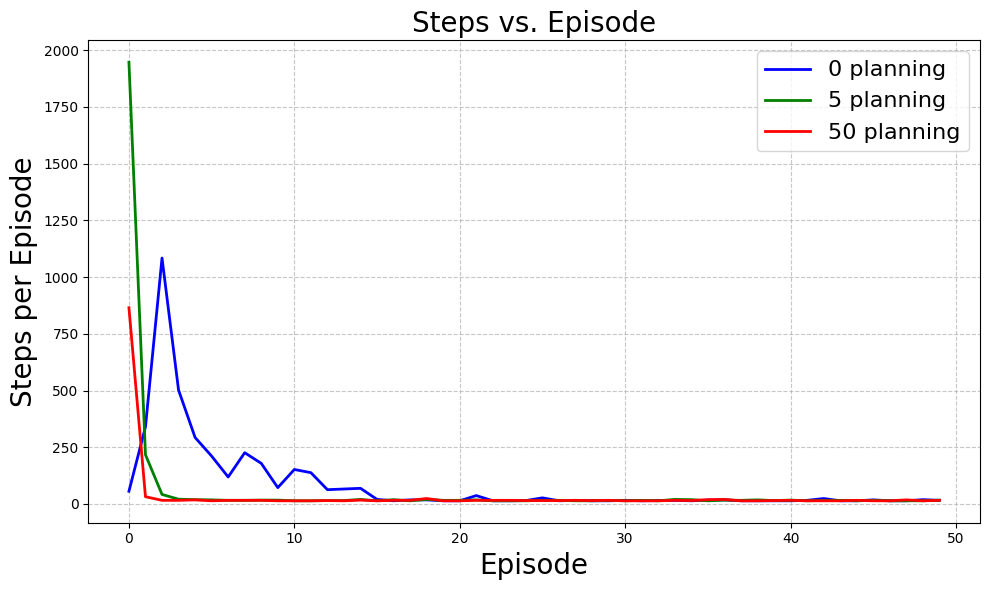

In [114]:
import matplotlib.pyplot as plt
import numpy as np


# avg_cumulative_rewards = np.mean(np.stack(Dyna_Q_agent_large.cumulative_rewards).T, axis=0)
# avg_cumulative_rewards_plus = np.mean(np.stack(Dyna_Q_plus_agent_large.cumulative_rewards).T, axis=0)
# avg_cumulative_rewards_action = np.mean(np.stack(Dyna_Q_action_agent_large.cumulative_rewards).T, axis=0)

# 2. Define the timesteps for the x-axis
timesteps = np.arange(len(Dyna_Q_agent_large.num_steps))

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(timesteps, Dyna_Q_agent_large.num_steps, label='0 planning', color='blue', linewidth=2)
plt.plot(timesteps, Dyna_Q_agent_large5.num_steps, label='5 planning', color='green', linewidth=2)
plt.plot(timesteps, Dyna_Q_agent_large50.num_steps, label='50 planning', color='red', linewidth=2)

# Adding labels and title
plt.xlabel('Episode', fontsize=20)
plt.ylabel('Steps per Episode', fontsize=20)
plt.title(f'Steps vs. Episode', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()

plt.show()

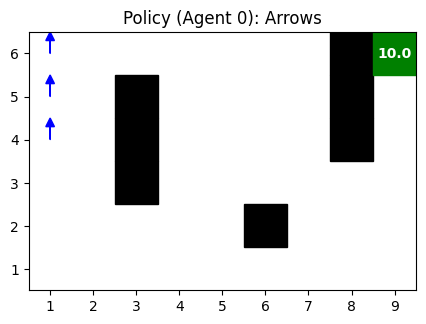

In [101]:
plot_optimal_policy(Dyna_Q_agent_large, figsize=(5, 5))

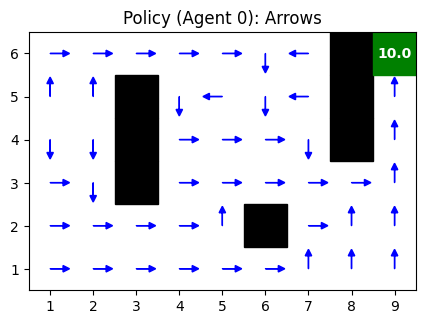

In [65]:
Dyna_Q_plus_agent_large.fixed_start_point = None
plot_optimal_policy(Dyna_Q_plus_agent_large, figsize=(5, 5))

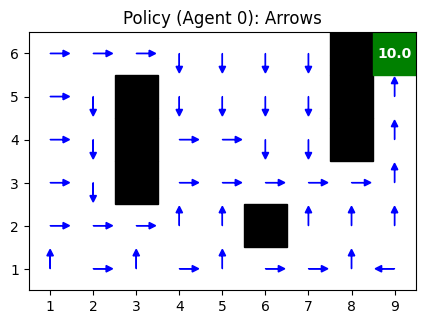

In [66]:
Dyna_Q_action_agent_large.fixed_start_point = None
plot_optimal_policy(Dyna_Q_action_agent_large, figsize=(5, 5))


~~~~~~~~~ Grid World ~~~~~~~~~
 6 |  .    .    .    .    .    .    .    .    G  |
 5 |  .    .    .    .    .    .    .    .    .  |
 4 |  .    .    .    .    .    .    .    .    .  |
 3 |  █    █    █    █    █    █    █    █    .  |
 2 |  .    .    .    .    .    .    .    .    .  |
 1 |  .    .    .    .    .    .    .    .    .  |
    ---------------------------------------------
      1    2    3    4    5    6    7    8    9  

--- Rewards ---
Goal at (9, 6): 1.00


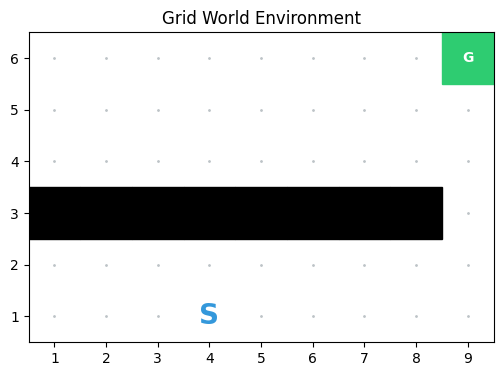


~~~~~~~~~ Grid World ~~~~~~~~~
 6 |  .    .    .    .    .    .    .    .    G  |
 5 |  .    .    .    .    .    .    .    .    .  |
 4 |  .    .    .    .    .    .    .    .    .  |
 3 |  .    █    █    █    █    █    █    █    █  |
 2 |  .    .    .    .    .    .    .    .    .  |
 1 |  .    .    .    .    .    .    .    .    .  |
    ---------------------------------------------
      1    2    3    4    5    6    7    8    9  

--- Rewards ---
Goal at (9, 6): 1.00


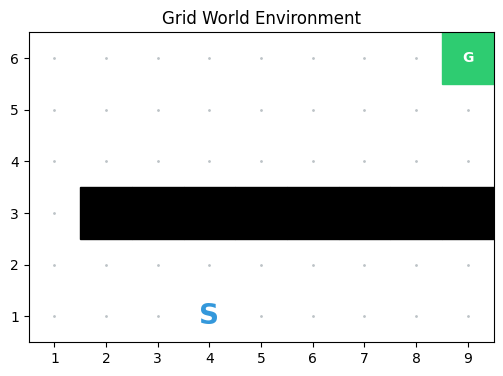

In [5]:
World3 = GridWorld(9, 6)
World3.add_goal(9, 6, reward=1.0)
World3.add_obstacles([(1, 3), (2, 3), (3, 3), (4, 3), (5, 3), (6, 3), (7, 3), (8,3)])
World3.display()
World3.plot_gridworld(start_pos=(4, 1), figsize=(6, 6))

World4 = GridWorld(9, 6)
World4.add_goal(9, 6, reward=1.0)
World4.add_obstacles([(2, 3), (3, 3), (4, 3), (5, 3), (6, 3), (7, 3), (8,3), (9, 3)])
World4.display()
World4.plot_gridworld(start_pos=(4, 1), figsize=(6, 6))

In [36]:
Dyna_Q_agent_large, Dyna_Q_plus_agent_large, Dyna_Q_action_agent_large = trains(World3, World3, max_timestep1=1000, max_timestep2=10000, num_agents=1
                                                                                ,set_zero=True, num_plan=5, alpha=1.0, epsilon=0.1, gamma=0.95, k=0.0001, starting_point=(4, 1))


100%|██████████| 9000/9000 [00:05<00:00, 1564.05it/s]


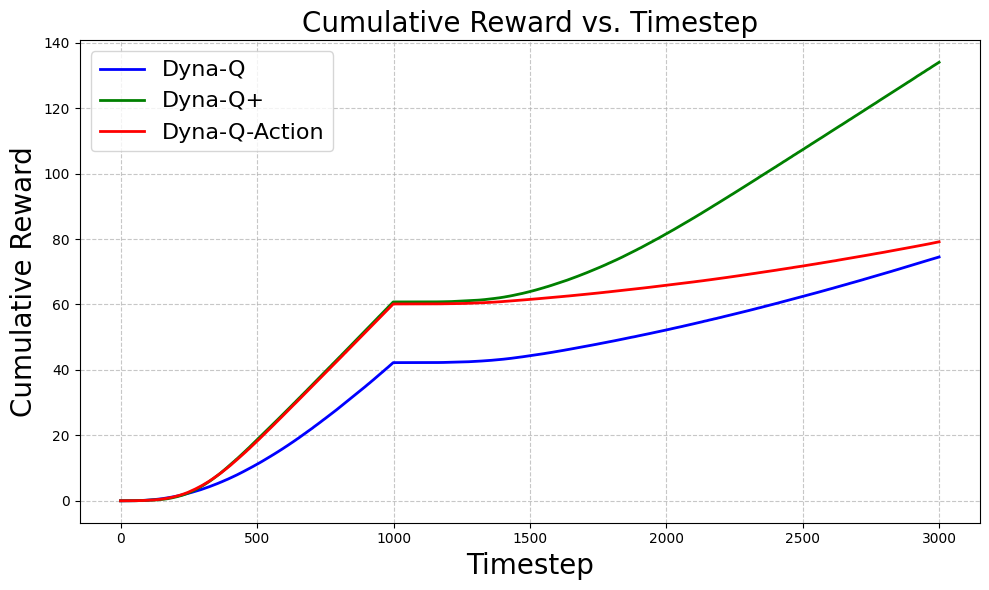

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


avg_cumulative_rewards = np.mean(np.stack(Dyna_Q_agent_large.cumulative_rewards).T, axis=0)
avg_cumulative_rewards_plus = np.mean(np.stack(Dyna_Q_plus_agent_large.cumulative_rewards).T, axis=0)
avg_cumulative_rewards_action = np.mean(np.stack(Dyna_Q_action_agent_large.cumulative_rewards).T, axis=0)

# 2. Define the timesteps for the x-axis
timesteps = np.arange(len(avg_cumulative_rewards))

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(timesteps, avg_cumulative_rewards, label='Dyna-Q', color='blue', linewidth=2)
plt.plot(timesteps, avg_cumulative_rewards_plus, label='Dyna-Q+', color='green', linewidth=2)
plt.plot(timesteps, avg_cumulative_rewards_action, label='Dyna-Q-Action', color='red', linewidth=2)

# Adding labels and title
plt.xlabel('Timestep', fontsize=20)
plt.ylabel('Cumulative Reward', fontsize=20)
plt.title(f'Cumulative Reward vs. Timestep', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()

plt.show()


~~~~~~~~~ Grid World ~~~~~~~~~
 6 |  .    .    .    .    .    .    .    .    G  |
 5 |  .    .    .    .    .    .    .    .    .  |
 4 |  .    .    .    .    .    .    .    .    .  |
 3 |  .    █    █    █    █    █    █    █    █  |
 2 |  .    .    .    .    .    .    .    .    .  |
 1 |  .    .    .    .    .    .    .    .    .  |
    ---------------------------------------------
      1    2    3    4    5    6    7    8    9  

--- Rewards ---
Goal at (9, 6): 1.00


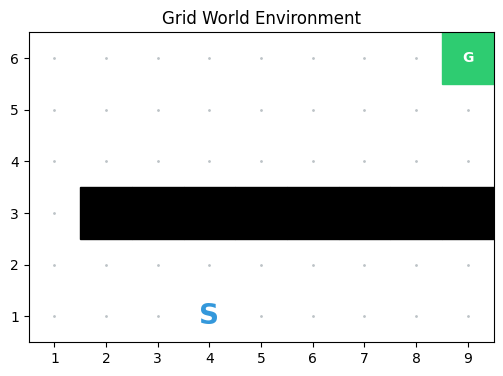


~~~~~~~~~ Grid World ~~~~~~~~~
 6 |  .    .    .    .    .    .    .    .    G  |
 5 |  .    .    .    .    .    .    .    .    .  |
 4 |  .    .    .    .    .    .    .    .    .  |
 3 |  .    █    █    █    █    █    █    █    .  |
 2 |  .    .    .    .    .    .    .    .    .  |
 1 |  .    .    .    .    .    .    .    .    .  |
    ---------------------------------------------
      1    2    3    4    5    6    7    8    9  

--- Rewards ---
Goal at (9, 6): 1.00


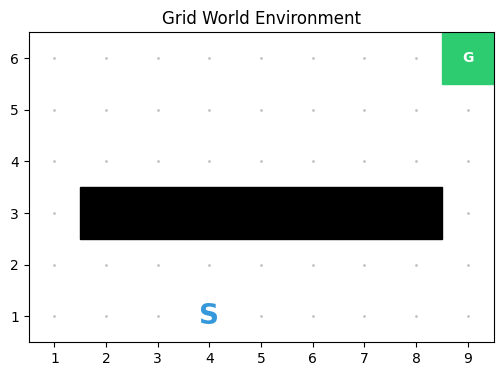

In [119]:
World5 = GridWorld(9, 6)
World5.add_goal(9, 6, reward=1.0)
World5.add_obstacles([(2, 3), (3, 3), (4, 3), (5, 3), (6, 3), (7, 3), (8,3), (9, 3)])
World5.display()
World5.plot_gridworld(start_pos=(4, 1), figsize=(6, 6))

World6 = GridWorld(9, 6)
World6.add_goal(9, 6, reward=1.0)
World6.add_obstacles([(2, 3), (3, 3), (4, 3), (5, 3), (6, 3), (7, 3), (8,3)])
World6.display()
World6.plot_gridworld(start_pos=(4, 1), figsize=(6, 6))

In [120]:
Dyna_Q_agent_large, Dyna_Q_plus_agent_large, Dyna_Q_action_agent_large = trains(World5, World6, max_timestep1=3000, max_timestep2=6000, num_agents=1000
                                                                                , set_zero=True, num_plan=50, alpha=1.0, epsilon=0.1, gamma=0.95, k=0.001, starting_point=(4, 1))


100%|██████████| 3000/3000 [59:59<00:00,  1.20s/it]  


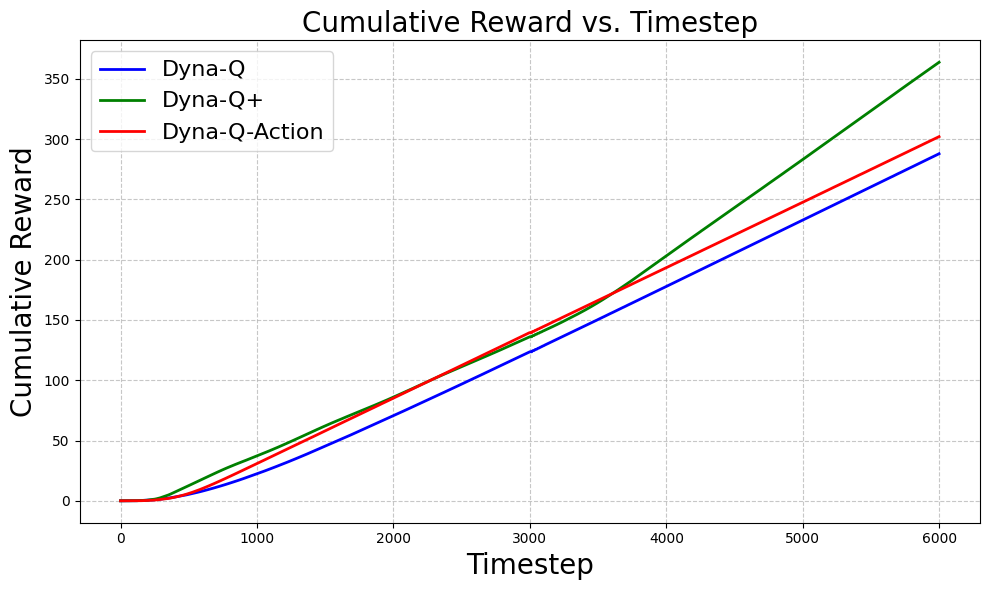

In [121]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the mean reward across all agents at each timestep
# Shape of cumulative_rewards is (num_agents, max_timestep)
avg_cumulative_rewards = np.mean(np.stack(Dyna_Q_agent_large.cumulative_rewards).T, axis=0)
avg_cumulative_rewards_plus = np.mean(np.stack(Dyna_Q_plus_agent_large.cumulative_rewards).T, axis=0)
avg_cumulative_rewards_action = np.mean(np.stack(Dyna_Q_action_agent_large.cumulative_rewards).T, axis=0)

# 2. Define the timesteps for the x-axis
timesteps = np.arange(len(avg_cumulative_rewards))

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(timesteps, avg_cumulative_rewards, label='Dyna-Q', color='blue', linewidth=2)
plt.plot(timesteps, avg_cumulative_rewards_plus, label='Dyna-Q+', color='green', linewidth=2)
plt.plot(timesteps, avg_cumulative_rewards_action, label='Dyna-Q-Action', color='red', linewidth=2)

# Adding labels and title
plt.xlabel('Timestep', fontsize=20)
plt.ylabel('Cumulative Reward', fontsize=20)
plt.title(f'Cumulative Reward vs. Timestep', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()

plt.show()


~~~~~~~~~ Grid World ~~~~~~~~~
15 |  .    █    .    .    .    █    .    █    .    █    .    █    .    █    G  |
14 |  .    █    .    █    █    █    .    █    .    █    .    █    .    █    .  |
13 |  .    .    .    .    .    █    .    .    .    .    .    .    .    .    .  |
12 |  █    █    .    █    █    █    .    █    █    █    .    █    █    █    █  |
11 |  .    █    .    █    .    .    .    █    .    .    .    █    .    █    .  |
10 |  .    █    .    █    .    █    .    █    █    █    █    █    .    █    .  |
 9 |  .    .    .    █    .    █    .    .    .    .    .    █    .    █    .  |
 8 |  █    █    .    █    .    █    █    █    █    █    █    █    .    █    .  |
 7 |  .    .    .    █    .    █    .    .    .    .    .    █    .    .    .  |
 6 |  █    █    .    █    .    █    █    █    .    █    █    █    .    █    █  |
 5 |  .    █    .    █    .    .    .    .    .    █    .    .    .    .    .  |
 4 |  .    █    .    █    .    █    █    █    █    █    █    █    .    █    █

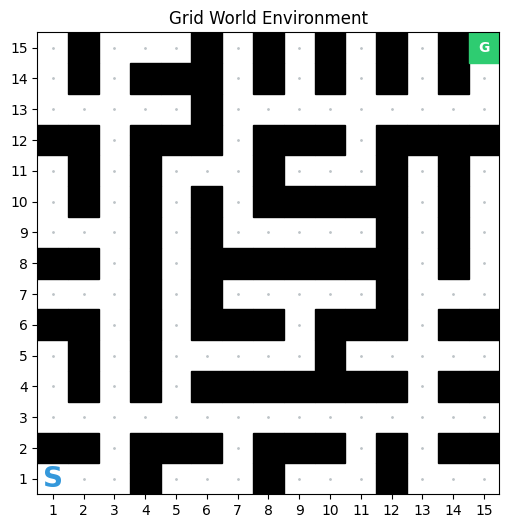


~~~~~~~~~ Grid World ~~~~~~~~~
15 |  .    █    .    .    .    █    .    █    .    █    .    █    .    █    G  |
14 |  .    █    .    █    █    █    .    █    .    █    .    █    .    █    .  |
13 |  .    .    .    .    .    █    .    .    .    .    .    .    .    █    .  |
12 |  █    █    .    █    █    █    .    █    █    █    .    █    █    █    .  |
11 |  .    █    .    █    .    .    .    █    .    .    .    █    .    █    .  |
10 |  .    █    .    █    .    █    .    █    █    █    █    █    .    █    .  |
 9 |  .    .    .    █    .    █    .    .    .    .    .    █    .    █    .  |
 8 |  █    █    .    █    .    █    █    █    █    █    █    █    .    █    .  |
 7 |  .    .    .    █    .    █    .    .    .    .    .    █    .    .    .  |
 6 |  █    █    .    █    .    █    █    █    .    █    █    █    .    █    █  |
 5 |  .    █    .    █    .    .    .    .    .    █    .    .    .    .    .  |
 4 |  .    █    .    █    .    █    █    █    █    █    █    █    .    █    █

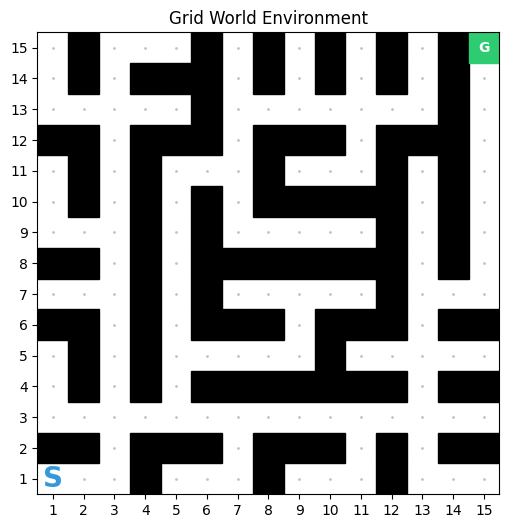

In [5]:
import copy
World7 = GridWorld(15, 15)
World7.generate_maze_prims(seed=42)
World7.add_goal(15, 15, reward=1.0)
World7.display()
World7.plot_gridworld(start_pos=(1, 1), figsize=(6, 6))

World8 = copy.deepcopy(World7)
World8.remove_obstacle(15,12)
World8.add_obstacle(14, 13)
World8.display()
World8.plot_gridworld(start_pos=(1, 1), figsize=(6, 6))

In [194]:
Dyna_Q_agent_large, Dyna_Q_plus_agent_large, Dyna_Q_action_agent_large = trains(World7, World8, max_timestep1=10000, max_timestep2=20000, num_agents=20
                                                                                , set_zero=True, num_plan=50, alpha=1.0, epsilon=0.1, gamma=0.95, k=0.0001, starting_point=(1, 1))


100%|██████████| 10000/10000 [02:52<00:00, 58.10it/s]


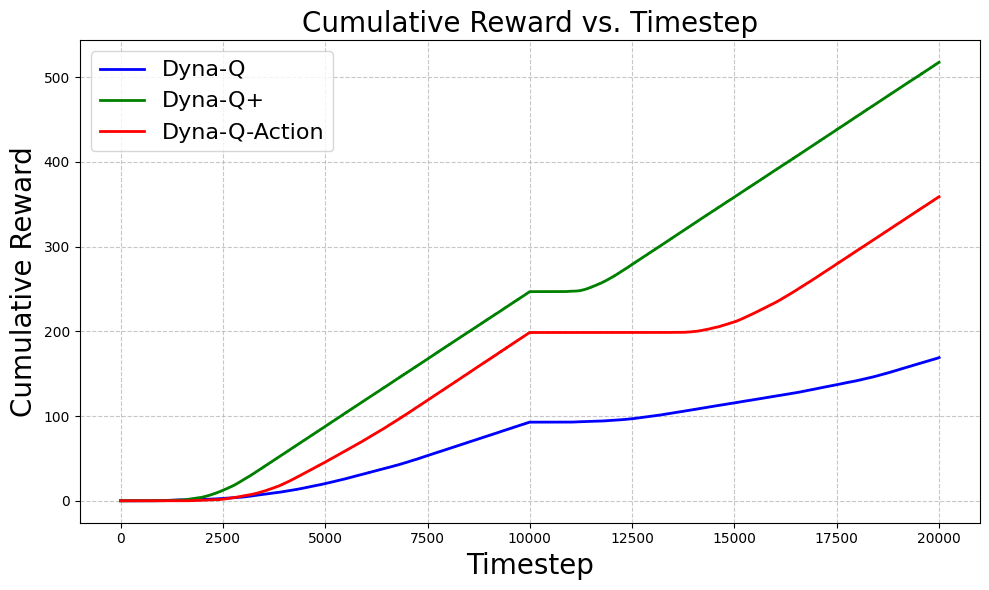

In [195]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the mean reward across all agents at each timestep
# Shape of cumulative_rewards is (num_agents, max_timestep)
avg_cumulative_rewards = np.mean(np.stack(Dyna_Q_agent_large.cumulative_rewards).T, axis=0)
avg_cumulative_rewards_plus = np.mean(np.stack(Dyna_Q_plus_agent_large.cumulative_rewards).T, axis=0)
avg_cumulative_rewards_action = np.mean(np.stack(Dyna_Q_action_agent_large.cumulative_rewards).T, axis=0)

# 2. Define the timesteps for the x-axis
timesteps = np.arange(len(avg_cumulative_rewards))

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(timesteps, avg_cumulative_rewards, label='Dyna-Q', color='blue', linewidth=2)
plt.plot(timesteps, avg_cumulative_rewards_plus, label='Dyna-Q+', color='green', linewidth=2)
plt.plot(timesteps, avg_cumulative_rewards_action, label='Dyna-Q-Action', color='red', linewidth=2)

# Adding labels and title
plt.xlabel('Timestep', fontsize=20)
plt.ylabel('Cumulative Reward', fontsize=20)
plt.title(f'Cumulative Reward vs. Timestep', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()

plt.show()

In [243]:
import copy
World9 = GridWorld(50, 3)
World9.add_obstacles([(x, 2) for x in range(2, 51)])
# World9.random_world(num_obstacles=200, num_goals=1, reward_range=(1.0, 1.0), seed=43)
World9.add_goal(50, 1, reward=1.0)
World9.add_goal(50, 3, reward=5.0)

# World9.remove_obstacle(10, 3)
World9.display()
# World9.plot_gridworld(start_pos=(2, 7), figsize=(6, 6))

World10 = copy.deepcopy(World9)
World10.remove_goal(50, 3)
World10.add_goal(50, 3, reward=-10.0)
World10.display()



~~~~~~~~~ Grid World ~~~~~~~~~
 3 |  .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    G  |
 2 |  .    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █    █  |
 1 |  .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    G  |
    ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [236]:
Dyna_Q_agent_large, Dyna_Q_plus_agent_large, Dyna_Q_action_agent_large = trains(World9, World10, max_timestep1=10000, max_timestep2=40000, num_agents=300
                                                                                , set_zero=True, num_plan=10, alpha=1., epsilon=0.1, gamma=0.95, k=0.0001, starting_point=(1, 2),
                                                                                starting_point2=(1, 2))


100%|██████████| 30000/30000 [1:06:45<00:00,  7.49it/s]


In [242]:
Dyna_Q_agent_large.world.display()


~~~~~~~~~ Grid World ~~~~~~~~~
 3 |  .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    G    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    .    . 

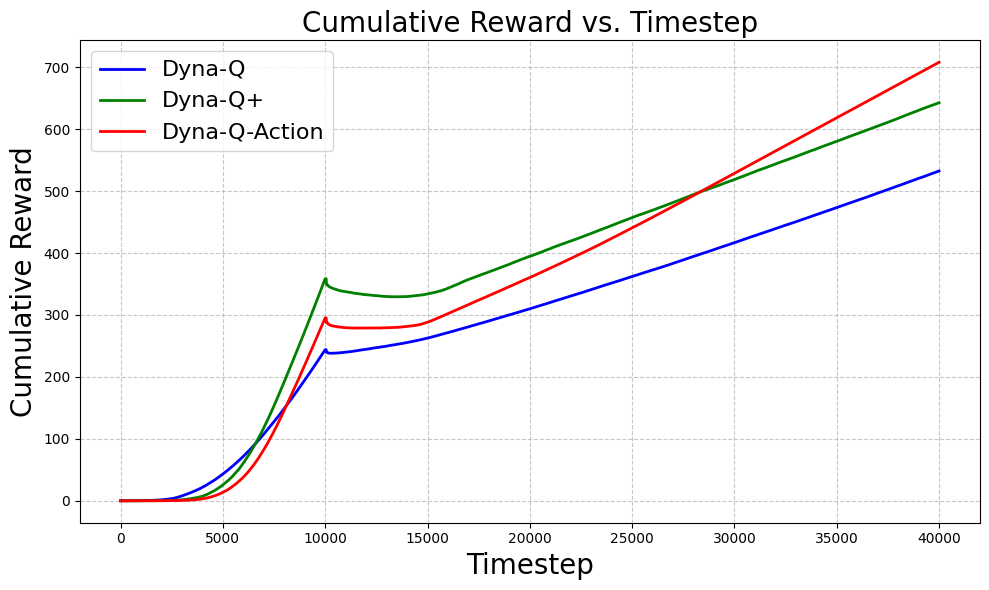

In [237]:
import matplotlib.pyplot as plt
import numpy as np


avg_cumulative_rewards = np.mean(np.stack(Dyna_Q_agent_large.cumulative_rewards).T, axis=0)
avg_cumulative_rewards_plus = np.mean(np.stack(Dyna_Q_plus_agent_large.cumulative_rewards).T, axis=0)
avg_cumulative_rewards_action = np.mean(np.stack(Dyna_Q_action_agent_large.cumulative_rewards).T, axis=0)

# 2. Define the timesteps for the x-axis
timesteps = np.arange(len(avg_cumulative_rewards))

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(timesteps, avg_cumulative_rewards, label='Dyna-Q', color='blue', linewidth=2)
plt.plot(timesteps, avg_cumulative_rewards_plus, label='Dyna-Q+', color='green', linewidth=2)
plt.plot(timesteps, avg_cumulative_rewards_action, label='Dyna-Q-Action', color='red', linewidth=2)

# Adding labels and title
plt.xlabel('Timestep', fontsize=20)
plt.ylabel('Cumulative Reward', fontsize=20)
plt.title(f'Cumulative Reward vs. Timestep', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()

plt.show()

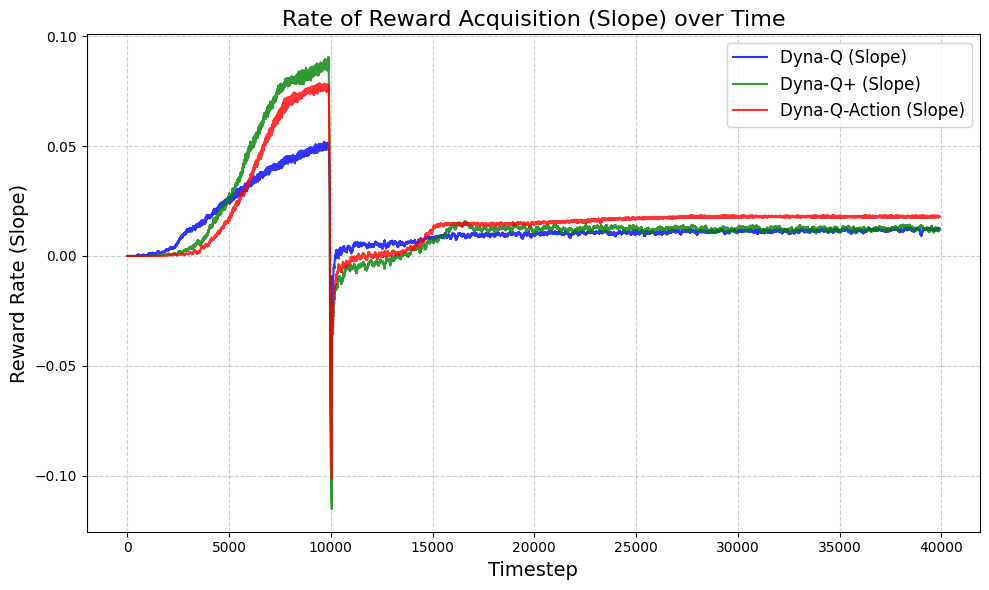

In [239]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the slopes (differences)
# We use np.diff to get the reward per timestep
slope_q = np.diff(avg_cumulative_rewards)
slope_plus = np.diff(avg_cumulative_rewards_plus)
slope_action = np.diff(avg_cumulative_rewards_action)

# 2. Optional: Smooth the data for better visualization
# This makes the "rate of learning" much easier to see
def smooth(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

window_size = 100
s_slope_q = smooth(slope_q, window_size)
s_slope_plus = smooth(slope_plus, window_size)
s_slope_action = smooth(slope_action, window_size)

# 3. Create the plot
plt.figure(figsize=(10, 6))
t_axis = np.arange(len(s_slope_q))

plt.plot(t_axis, s_slope_q, label='Dyna-Q (Slope)', color='blue', alpha=0.8)
plt.plot(t_axis, s_slope_plus, label='Dyna-Q+ (Slope)', color='green', alpha=0.8)
plt.plot(t_axis, s_slope_action, label='Dyna-Q-Action (Slope)', color='red', alpha=0.8)

plt.xlabel('Timestep', fontsize=14)
plt.ylabel('Reward Rate (Slope)', fontsize=14)
plt.title('Rate of Reward Acquisition (Slope) over Time', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()